In [18]:
import pandas as pd

In [19]:
df=pd.read_csv("social media .csv")

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  str    
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  str    
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  str    
 5   content_category          29999 non-null  str    
 6   traffic_source            29999 non-null  str    
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  str    
 9   post_date                 29999 non-null  str    
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  str    
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares           

In [21]:
df.isna().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

Train Accuracy: 1.0
Test Accuracy: 0.84

Classification Report:

              precision    recall  f1-score   support

        high       0.84      0.79      0.81      1449
         low       0.89      0.87      0.88      1545
      medium       0.86      0.78      0.82      1510
       viral       0.78      0.93      0.84      1496

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000


Confusion Matrix:

[[1143   28   75  203]
 [  55 1338  105   47]
 [  74  114 1175  147]
 [  85   23    4 1384]]


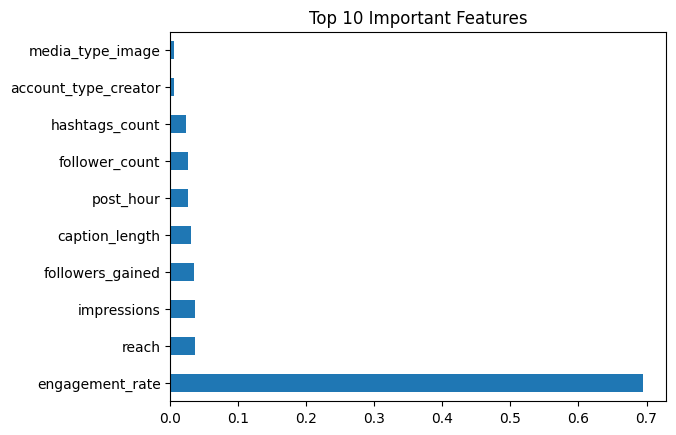

In [33]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 2. Clean Column Names
# ==============================
df.columns = df.columns.str.strip()

# ==============================
# 3. Define Target
# ==============================
y = df['performance_bucket_label']

# ==============================
# 4. Drop Unnecessary Columns
# ==============================
X = df.drop(columns=[
    'post_id', 
    'account_id',
    'likes', 'comments', 'shares', 'saves',   # data leakage
    'post_datetime', 'post_date',             # raw datetime
    'performance_bucket_label'                # target
], errors='ignore')

# ==============================
# 5. Encode Categorical Variables
# ==============================
X = pd.get_dummies(X, drop_first=True)

# ==============================
# 6. Train-Test Split
# ==============================
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Train Model
# ==============================
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train, y_train)

# ==============================
# 8. Predictions
# ==============================
y_pred_train = rfc.predict(x_train)
y_pred_test = rfc.predict(x_test)

# ==============================
# 9. Evaluation
# ==============================
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_test))

# ==============================
# 10. Feature Importance (IMPORTANT)
# ==============================
import matplotlib.pyplot as plt

feature_importance = pd.Series(rfc.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [34]:
import pickle

# Save
with open('model.pkl', 'wb') as f:
    pickle.dump(rfc, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(X.columns, f)

# Load
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('columns.pkl', 'rb') as f:
    columns = pickle.load(f)